Estimating the value of a used car is one of the main everyday challenges in the automotive business. We believe that the sales price of a car is not only based on the value of the product itself, but is also heavily influenced by things like market trends, current availability, and politics.
With this challenge, we hope to raise some interest in this exciting topic and also gain some insight into what the main factors are that drive the value of a used car.

The data provided consists of almost 5000 real BMW cars that were sold via a b2b auction in 2018. The price shown in the table is the highest bid that was reached during the auction.

We have already done some data cleanup and filtered out cars with engine damage etc. However there may still be minor damages like scratches, but we do not have more information about that.

We have also extracted 8 criteria based on the equipment of cars that we think might have a good impact on the value of a used car. These criteria have been labeled feature1 to feature8 and are shown in the data below.

## 0. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import root_mean_squared_error, r2_score
import bisect

import warnings
warnings.filterwarnings('ignore')

##  1. Reading data

In [2]:
df = pd.read_csv("data/bmw_pricing_challenge.csv")

In [3]:
df.head()

,maker_key,model_key,mileage,engine_power,registration_date,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price,sold_at
0,BMW,118,140411,100,2012-02-01,diesel,black,convertible,True,True,False,False,True,True,True,False,11300,2018-01-01
1,BMW,M4,13929,317,2016-04-01,petrol,grey,convertible,True,True,False,False,False,True,True,True,69700,2018-02-01
2,BMW,320,183297,120,2012-04-01,diesel,white,convertible,False,False,False,False,True,False,True,False,10200,2018-02-01
3,BMW,420,128035,135,2014-07-01,diesel,red,convertible,True,True,False,False,True,True,True,True,25100,2018-02-01
4,BMW,425,97097,160,2014-12-01,diesel,silver,convertible,True,True,False,False,False,True,True,True,33400,2018-04-01


In [4]:
df.shape

(4843, 18)

In [5]:
df.describe()

,mileage,engine_power,price
count,4.843000e+03,4843.00000,4843.000000
mean,1.409628e+05,128.98823,15828.081767
std,6.019674e+04,38.99336,9220.285684
min,-6.400000e+01,0.00000,100.000000
25%,1.029135e+05,100.00000,10800.000000
50%,1.410800e+05,120.00000,14200.000000
75%,1.751955e+05,135.00000,18600.000000
max,1.000376e+06,423.00000,178500.000000


## 2. Exploratory Data Analysis

### 2.1. Missing Values

Check if the dataset contains any missing values.

In [6]:
df.isnull().sum()

maker_key            0
model_key            0
mileage              0
engine_power         0
registration_date    0
fuel                 0
paint_color          0
car_type             0
feature_1            0
feature_2            0
feature_3            0
feature_4            0
feature_5            0
feature_6            0
feature_7            0
feature_8            0
price                0
sold_at              0
dtype: int64

### 2.2. Distribution of the target variable

Plot the probabilistic distribution of the target variable.

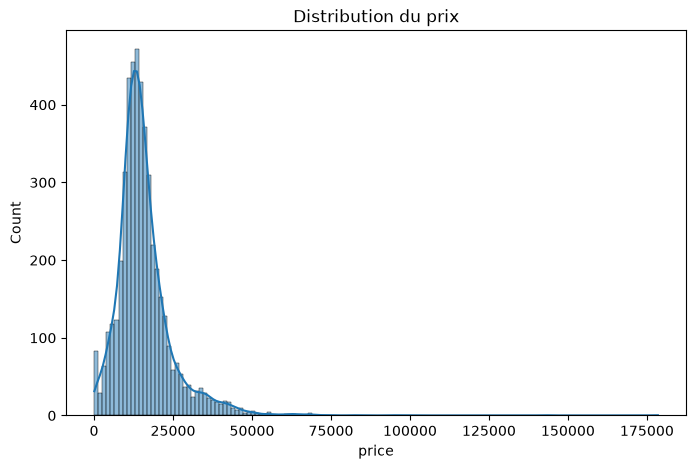

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True)
plt.title("Distribution du prix")
plt.show()

### 2.3. Distribution of numerical variables

Plot the probabilistic distribution of the numerical features.

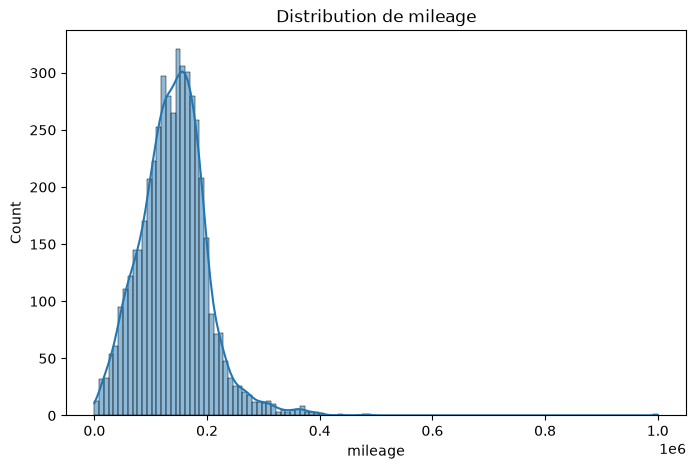

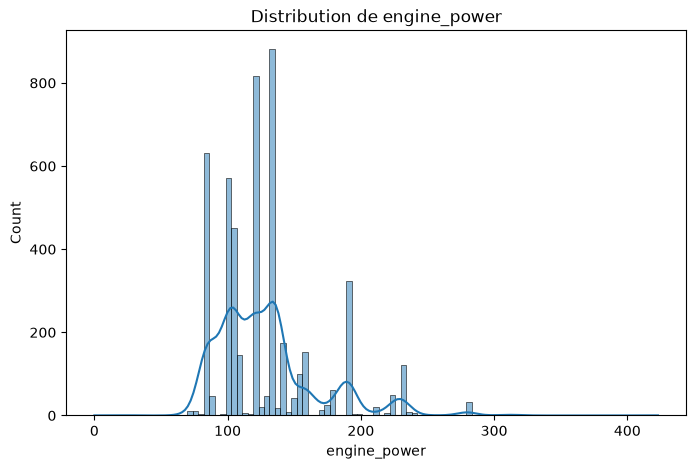

In [8]:
colonnes_numeriques = ['mileage', 'engine_power']

for colonne in colonnes_numeriques:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[colonne], kde=True)
    plt.title("Distribution de " + colonne)
    plt.show()

### 2.4. Histogram of categorical variables

Plot the histogram of the categorical features.

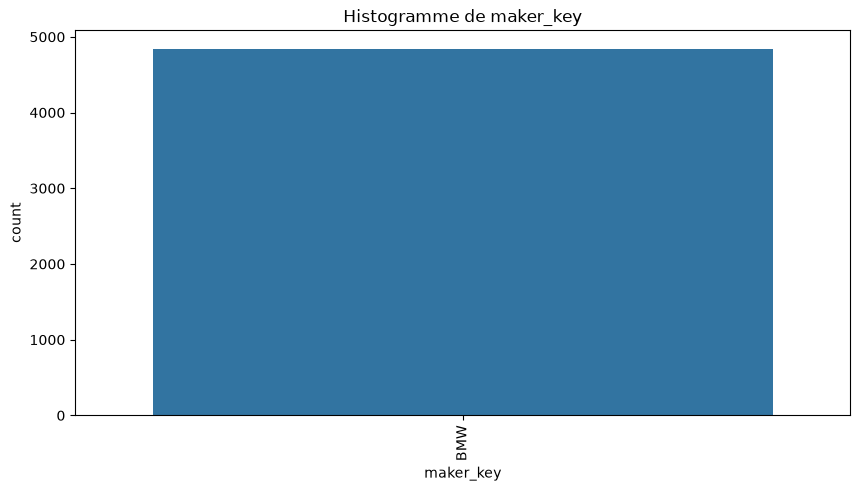

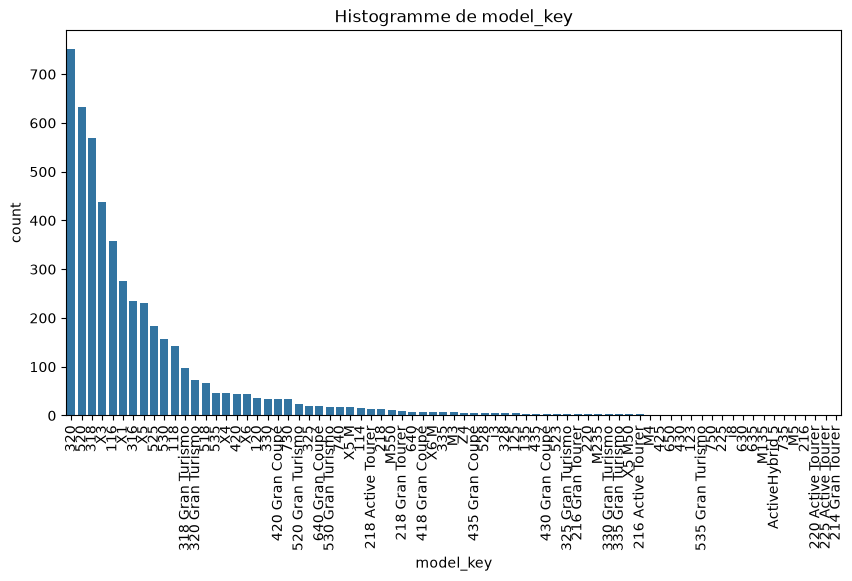

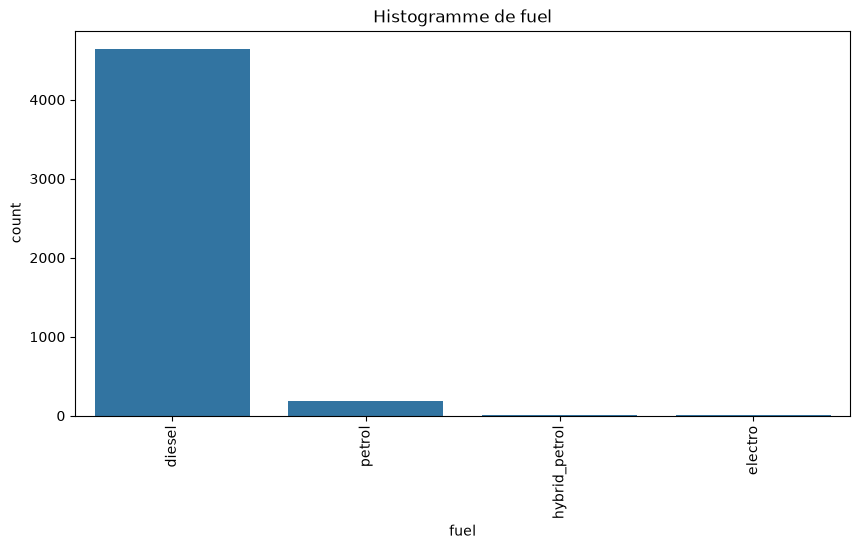

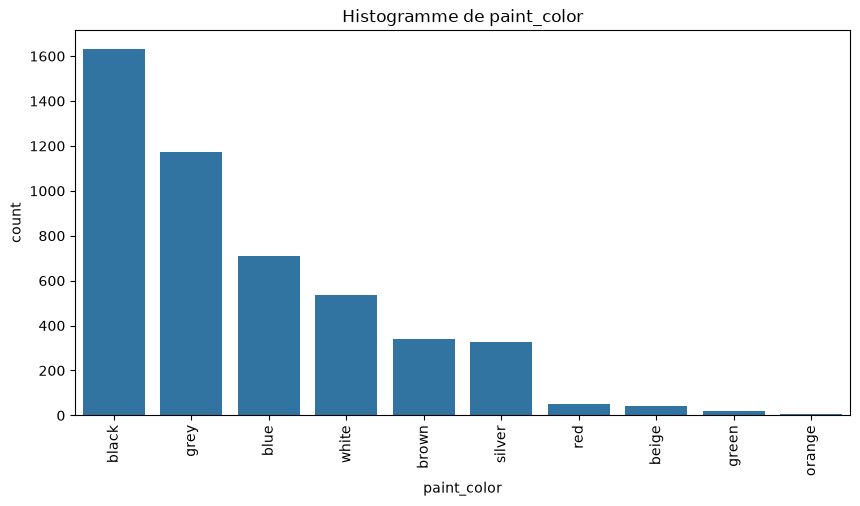

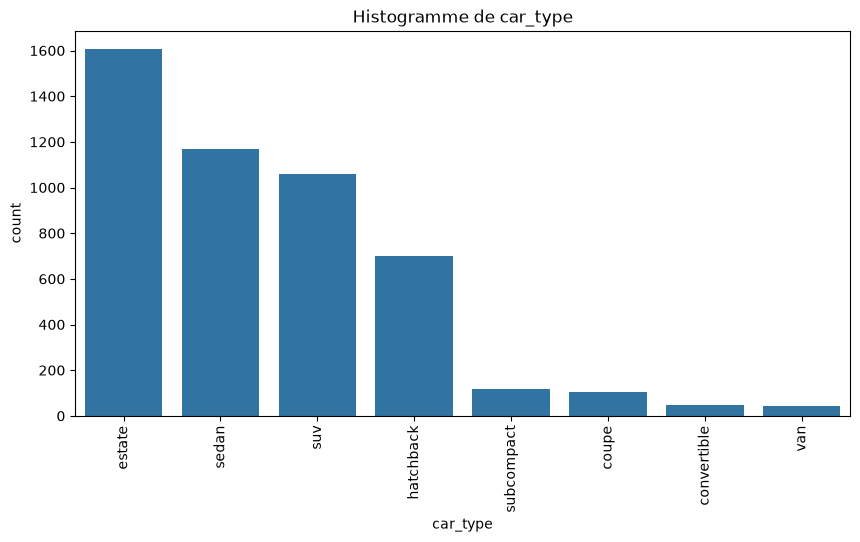

In [9]:
colonnes_categories = ['maker_key', 'model_key', 'fuel', 'paint_color', 'car_type']

for colonne in colonnes_categories:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df[colonne], order=df[colonne].value_counts().index)
    plt.title("Histogramme de " + colonne)
    plt.xticks(rotation=90)
    plt.show()

## 3. Data Splitting

Split the dataset into 2 training and test datasets.

In [10]:
donnees_train, donnees_test = train_test_split(df, test_size=0.2, random_state=42)

print(donnees_train.shape)
print(donnees_test.shape)

(3874, 18)
(969, 18)


## 4. Feature Engineering

### 4.1. Removing non-predictive features

Remove any unnecessary feature.

In [11]:
donnees_train['age_voiture'] = pd.to_datetime(donnees_train['sold_at']).dt.year - pd.to_datetime(donnees_train['registration_date']).dt.year
donnees_test['age_voiture'] = pd.to_datetime(donnees_test['sold_at']).dt.year - pd.to_datetime(donnees_test['registration_date']).dt.year

colonnes_a_enlever = ['maker_key', 'registration_date', 'sold_at']

x_entrainement = donnees_train.drop(columns=colonnes_a_enlever + ['price'])
y_entrainement = donnees_train['price']

x_test = donnees_test.drop(columns=colonnes_a_enlever + ['price'])
y_test = donnees_test['price']

x_entrainement.head()

,model_key,mileage,engine_power,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,age_voiture
1215,520,119515,135,diesel,grey,estate,False,True,False,False,True,False,True,True,4
432,320,234365,135,diesel,black,estate,True,True,False,False,True,False,True,True,3
4244,X3,77356,105,diesel,black,suv,False,True,False,False,False,False,True,False,5
289,318,181297,105,diesel,brown,estate,False,True,False,False,True,True,True,True,4
2585,320,144089,137,petrol,black,sedan,True,True,False,False,True,False,True,False,6


### 4.2. Creating new features

Creating polynomial features for numerical columns

In [12]:
colonnes_numeriques = ['mileage', 'engine_power', 'age_voiture']

polynome = PolynomialFeatures(degree=2, include_bias=False)

nouvelles_colonnes_train = polynome.fit_transform(x_entrainement[colonnes_numeriques])
nouvelles_colonnes_test = polynome.transform(x_test[colonnes_numeriques])

noms_colonnes = polynome.get_feature_names_out(colonnes_numeriques)

nouvelles_colonnes_train = pd.DataFrame(nouvelles_colonnes_train, columns=noms_colonnes, index=x_entrainement.index)
nouvelles_colonnes_test = pd.DataFrame(nouvelles_colonnes_test, columns=noms_colonnes, index=x_test.index)

x_entrainement = x_entrainement.drop(columns=colonnes_numeriques)
x_test = x_test.drop(columns=colonnes_numeriques)

x_entrainement = pd.concat([x_entrainement, nouvelles_colonnes_train], axis=1)
x_test = pd.concat([x_test, nouvelles_colonnes_test], axis=1)

x_entrainement.head()

,model_key,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_8,mileage,engine_power,age_voiture,mileage^2,mileage engine_power,mileage age_voiture,engine_power^2,engine_power age_voiture,age_voiture^2
1215,520,diesel,grey,estate,False,True,False,False,True,False,...,True,119515.0,135.0,4.0,1.428384e+10,16134525.0,478060.0,18225.0,540.0,16.0
432,320,diesel,black,estate,True,True,False,False,True,False,...,True,234365.0,135.0,3.0,5.492695e+10,31639275.0,703095.0,18225.0,405.0,9.0
4244,X3,diesel,black,suv,False,True,False,False,False,False,...,False,77356.0,105.0,5.0,5.983951e+09,8122380.0,386780.0,11025.0,525.0,25.0
289,318,diesel,brown,estate,False,True,False,False,True,True,...,True,181297.0,105.0,4.0,3.286860e+10,19036185.0,725188.0,11025.0,420.0,16.0
2585,320,petrol,black,sedan,True,True,False,False,True,False,...,False,144089.0,137.0,6.0,2.076164e+10,19740193.0,864534.0,18769.0,822.0,36.0


### 4.3. Scaling numerical variables

In [13]:
colonnes_a_mettre_a_lechelle = list(noms_colonnes)

echelle = StandardScaler()

x_entrainement[colonnes_a_mettre_a_lechelle] = echelle.fit_transform(x_entrainement[colonnes_a_mettre_a_lechelle])
x_test[colonnes_a_mettre_a_lechelle] = echelle.transform(x_test[colonnes_a_mettre_a_lechelle])

x_entrainement.head()

,model_key,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_8,mileage,engine_power,age_voiture,mileage^2,mileage engine_power,mileage age_voiture,engine_power^2,engine_power age_voiture,age_voiture^2
1215,520,diesel,grey,estate,False,True,False,False,True,False,...,True,-0.361618,0.150473,-0.609847,-0.371363,-0.211394,-0.488058,0.001059,-0.459441,-0.449290
432,320,diesel,black,estate,True,True,False,False,True,False,...,True,1.521564,0.150473,-1.002558,1.221199,1.433443,-0.204268,0.001059,-0.830534,-0.596813
4244,X3,diesel,black,suv,False,True,False,False,False,False,...,False,-1.052894,-0.611134,-0.217137,-0.696586,-1.061370,-0.603171,-0.559328,-0.500674,-0.259619
289,318,diesel,brown,estate,False,True,False,False,True,True,...,True,0.651414,-0.611134,-0.609847,0.356863,0.096432,-0.176406,-0.559328,-0.789301,-0.449290
2585,320,petrol,black,sedan,True,True,False,False,True,False,...,False,0.041319,0.201247,0.175574,-0.117536,0.171117,-0.000678,0.043400,0.315729,-0.027798


### 4.4. Categorical variables encoding

Convert categorical columns into numerical columns using label encoding or one-hot encoding.

In [14]:
colonnes_texte = ['model_key', 'fuel', 'paint_color', 'car_type']

x_entrainement = pd.get_dummies(x_entrainement, columns=colonnes_texte, drop_first=True)
x_test = pd.get_dummies(x_test, columns=colonnes_texte, drop_first=True)

x_test = x_test.reindex(columns=x_entrainement.columns, fill_value=0)

x_entrainement.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,mileage,engine_power,...,paint_color_red,paint_color_silver,paint_color_white,car_type_coupe,car_type_estate,car_type_hatchback,car_type_sedan,car_type_subcompact,car_type_suv,car_type_van
1215,False,True,False,False,True,False,True,True,-0.361618,0.150473,...,False,False,False,False,True,False,False,False,False,False
432,True,True,False,False,True,False,True,True,1.521564,0.150473,...,False,False,False,False,True,False,False,False,False,False
4244,False,True,False,False,False,False,True,False,-1.052894,-0.611134,...,False,False,False,False,False,False,False,False,True,False
289,False,True,False,False,True,True,True,True,0.651414,-0.611134,...,False,False,False,False,True,False,False,False,False,False
2585,True,True,False,False,True,False,True,False,0.041319,0.201247,...,False,False,False,False,False,False,True,False,False,False


### 4.5. Converting boolean columns

In [15]:
for colonne in x_entrainement.columns:
    if x_entrainement[colonne].dtype == bool:
        x_entrainement[colonne] = x_entrainement[colonne].astype(int)
        x_test[colonne] = x_test[colonne].astype(int)

x_entrainement.dtypes.value_counts()

int64      100
float64      9
Name: count, dtype: int64

## 5. Linear Regression

Fit a linear regression model on the training set. Evaluate the model on the testing set. Use the $R^2$ as an evaluation metric.

In [16]:
modele_lineaire = LinearRegression()
modele_lineaire.fit(x_entrainement, y_entrainement)

predictions_lineaire = modele_lineaire.predict(x_test)

print("R2 :", r2_score(y_test, predictions_lineaire))

R2 : 0.8189232207017331


Plot feature importance/weight.

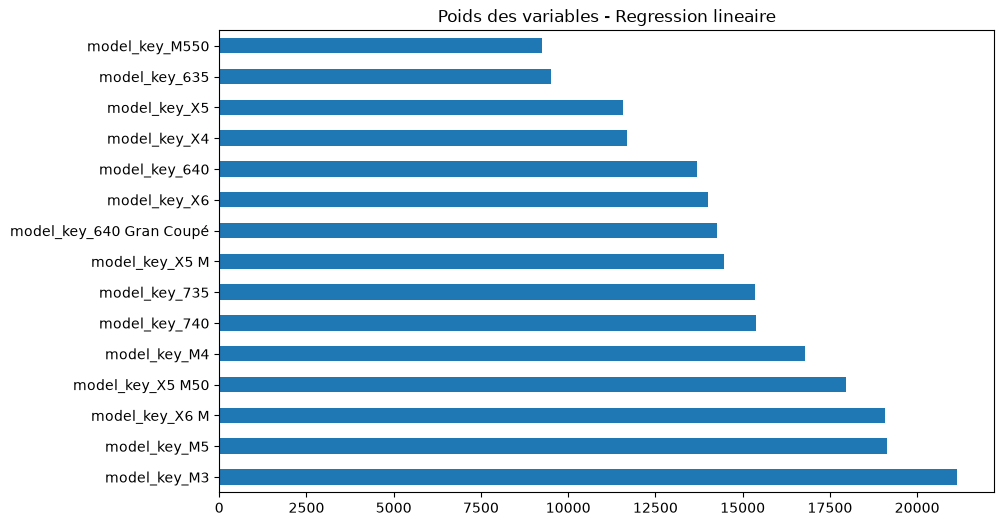

In [17]:
poids_lineaire = pd.Series(modele_lineaire.coef_, index=x_entrainement.columns)
plus_importants = poids_lineaire.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 6))
poids_lineaire[plus_importants].plot(kind='barh')
plt.title("Poids des variables - Regression lineaire")
plt.show()

## 6. Ridge

Fit a ridge regression model on the training set. Use cross-validation in order to tune the regularization parameter of the ridge model. Evaluate the model on the testing set. Use the $R^2$ as an evaluation metric.

In [18]:
valeurs_alpha = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

modele_ridge = RidgeCV(alphas=valeurs_alpha, cv=5)
modele_ridge.fit(x_entrainement, y_entrainement)

predictions_ridge = modele_ridge.predict(x_test)

print("Meilleur alpha :", modele_ridge.alpha_)
print("R2 :", r2_score(y_test, predictions_ridge))

Meilleur alpha : 1.0
R2 : 0.8244286792671446


Plot feature importance/weight.

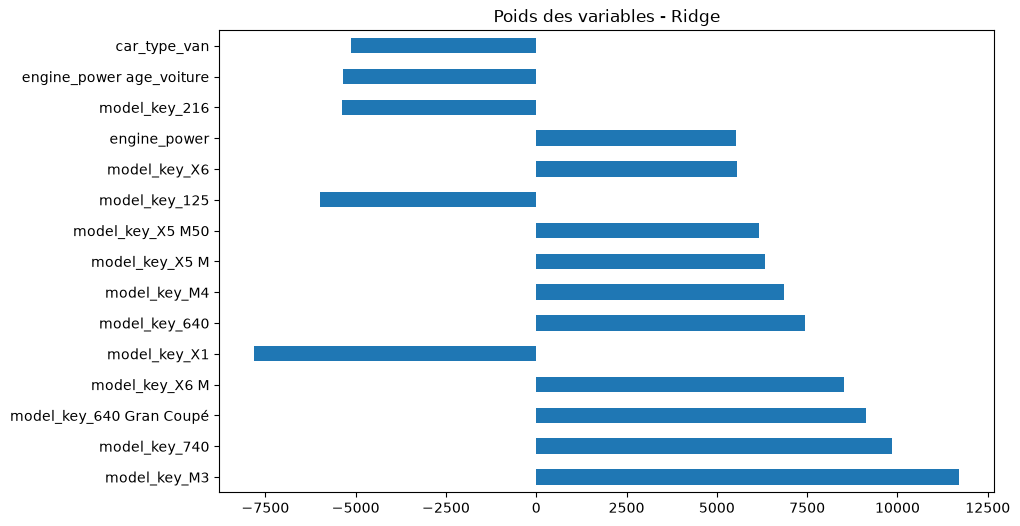

In [19]:
poids_ridge = pd.Series(modele_ridge.coef_, index=x_entrainement.columns)
plus_importants = poids_ridge.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 6))
poids_ridge[plus_importants].plot(kind='barh')
plt.title("Poids des variables - Ridge")
plt.show()

## 7. Lasso

Fit a lasso regression model on the training set. Use cross-validation in order to tune the regularization parameter of the lasso model. Evaluate the model on the testing set. Use the $R^2$ as an evaluation metric.

In [20]:
valeurs_alpha = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

modele_lasso = LassoCV(alphas=valeurs_alpha, cv=5, max_iter=10000)
modele_lasso.fit(x_entrainement, y_entrainement)

predictions_lasso = modele_lasso.predict(x_test)

print("Meilleur alpha :", modele_lasso.alpha_)
print("R2 :", r2_score(y_test, predictions_lasso))

Meilleur alpha : 1.0
R2 : 0.8236439404112514


Plot feature importance/weight.

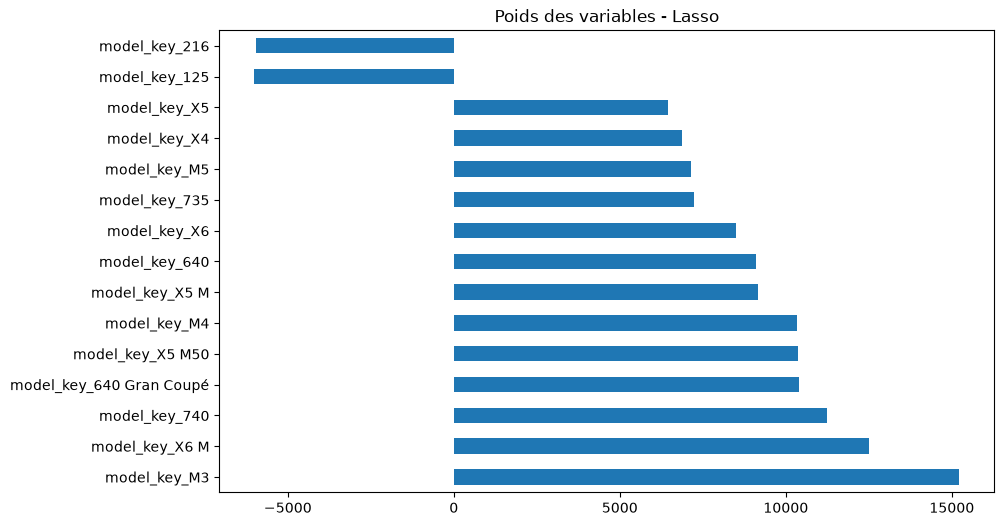

In [21]:
poids_lasso = pd.Series(modele_lasso.coef_, index=x_entrainement.columns)
plus_importants = poids_lasso.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 6))
poids_lasso[plus_importants].plot(kind='barh')
plt.title("Poids des variables - Lasso")
plt.show()